# Employee Attrition Analysis — End-to-End Project
### IBM HR Analytics Dataset | 1,470 Employees | 35 Features

**Author:** Data Analyst Project (Placement Portfolio)
**Tools:** Python 3, Pandas, NumPy, Matplotlib, Seaborn, SciPy

This notebook performs a complete, professional attrition analysis: data cleaning, feature engineering, exploratory data analysis, KPI computation, deep attrition analysis, statistical hypothesis testing, and business insights/recommendations.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100
pd.set_option('display.max_columns', None)

df = pd.read_csv('WA_Fn-UseC_-HR-Employee-Attrition.csv')
print("Shape:", df.shape)
df.head()

Shape: (1470, 35)


---
# Stage 1 — Dataset Inspection & Data Dictionary

## Target Variable
| Column | Type | Values | Meaning |
|---|---|---|---|
| **Attrition** | Binary Categorical | Yes / No | Did the employee leave the company? |

## Data Dictionary (abridged — full table in project report)

| Column | Nature | Business Meaning |
|---|---|---|
| Age | Continuous | Employee age; younger employees show higher attrition risk |
| BusinessTravel | Nominal | Travel frequency; frequent travel is a stress/attrition driver |
| Department | Nominal | Sales, R&D, HR |
| DistanceFromHome | Discrete | Commute distance; long commutes correlate with burnout |
| Education | Ordinal (1-5) | Education level |
| EnvironmentSatisfaction | Ordinal (1-4) | Satisfaction with work environment |
| Gender | Binary | Male/Female |
| JobInvolvement | Ordinal (1-4) | Engagement with job |
| JobLevel | Ordinal (1-5) | Seniority tier |
| JobRole | Nominal | Specific role |
| JobSatisfaction | Ordinal (1-4) | Core HR satisfaction metric |
| MaritalStatus | Nominal | Single/Married/Divorced |
| MonthlyIncome | Continuous | Primary compensation metric |
| NumCompaniesWorked | Discrete | Job-hopping history |
| OverTime | Binary | Known strong attrition driver |
| PerformanceRating | Ordinal (only 3,4 present) | Performance score |
| StockOptionLevel | Ordinal (0-3) | Equity retention incentive |
| TotalWorkingYears | Discrete | Total career experience |
| WorkLifeBalance | Ordinal (1-4) | 1=Bad ... 4=Best |
| YearsAtCompany | Discrete | Tenure — core loyalty metric |
| YearsSinceLastPromotion | Discrete | Career growth stagnation proxy |
| EmployeeCount, Over18, StandardHours | Constant | Zero variance — no analytical value |
| EmployeeNumber | Identifier | Not a feature |

**Numerical - Continuous:** Age, DailyRate, HourlyRate, MonthlyIncome, MonthlyRate
**Numerical - Discrete:** DistanceFromHome, NumCompaniesWorked, TotalWorkingYears, YearsAtCompany, YearsSinceLastPromotion, etc.
**Categorical - Nominal:** BusinessTravel, Department, EducationField, Gender, JobRole, MaritalStatus, OverTime
**Categorical - Ordinal (coded 1-4/1-5):** Education, EnvironmentSatisfaction, JobInvolvement, JobSatisfaction, WorkLifeBalance, RelationshipSatisfaction, StockOptionLevel


In [ ]:
df.dtypes
df.nunique().sort_values()

Over18                        1
EmployeeCount                 1
StandardHours                  1
PerformanceRating               2
...
EmployeeNumber              1470
dtype: int64


---
# Stage 2 — Data Cleaning

## 2.1 Constant Columns

**Problem:** `EmployeeCount`, `Over18`, `StandardHours` have only one unique value each.
**Reason:** Zero-variance columns carry no analytical or predictive information and add noise.
**Action:** Drop these 3 columns.


In [ ]:
for col in df.columns:
    if df[col].nunique() == 1:
        print(col, "->", df[col].unique())

EmployeeCount -> [1]
Over18 -> ['Y']
StandardHours -> [80]


In [ ]:
df_clean = df.drop(columns=['EmployeeCount','Over18','StandardHours'])
print("New shape:", df_clean.shape)

New shape: (1470, 32)


**Explanation:** All three columns had exactly one repeated value across all 1,470 rows, so they cannot explain any variation in attrition and are safely removed.

## 2.2 Missing Values
**Problem:** Check for nulls.
**Reason:** Missing data can bias statistics and break models.


In [ ]:
print(df_clean.isnull().sum().sum(), "total missing values")
print((df_clean.isnull().sum()/len(df_clean)*100).sum(), "% missing")

0 total missing values
0.0 % missing


**Output:** 0 missing values across all columns.
**Explanation:** This is a curated teaching dataset — real-world HR data almost always has missing values (e.g., unrecorded exit interviews), so in production this check should never be skipped even when it comes back clean.

## 2.3 Duplicate Rows & Duplicate Employee IDs
**Problem:** Check for exact duplicate rows and duplicate `EmployeeNumber` values.
**Reason:** Duplicates would double-count the same employee and inflate attrition statistics.


In [ ]:
print("Duplicate rows:", df_clean.duplicated().sum())
print("Duplicate EmployeeNumber:", df_clean['EmployeeNumber'].duplicated().sum())

Duplicate rows: 0
Duplicate EmployeeNumber: 0


**Output:** 0 duplicate rows, 0 duplicate IDs.
**Explanation:** Every employee is represented exactly once — safe to proceed without deduplication logic.

## 2.4 Data Types
**Problem:** Confirm each column's dtype matches its true nature (e.g., ordinal scales stored as int64 are fine to keep numeric-coded, but should be *treated* as categorical in EDA).
**Reason:** Wrong dtypes cause incorrect aggregations (e.g., averaging a nominal code) and wrong plot choices.
**Action:** No dtype conversion errors found — all columns already match sensible pandas dtypes (`int64` for numeric/ordinal-coded, `object` for text categories). We will *treat* the ordinal-coded columns (JobSatisfaction, WorkLifeBalance, etc.) as categorical during charting even though they remain int64 in the dataframe.

## 2.5 Leading/Trailing Spaces & Capitalization
**Problem:** Inconsistent spacing or casing in text categories (e.g., `'Sales '` vs `'Sales'`, `'sales'` vs `'Sales'`) silently creates duplicate categories.
**Reason:** These typos are common in manually-entered HR systems.


In [ ]:
obj_cols = df_clean.select_dtypes(include='object').columns
for c in obj_cols:
    issue = any(str(v) != str(v).strip() for v in df_clean[c].unique())
    print(f"{c:20s} unique={df_clean[c].nunique():3d}  whitespace_issue={issue}")

Attrition            unique=  2  whitespace_issue=False
BusinessTravel       unique=  3  whitespace_issue=False
Department           unique=  3  whitespace_issue=False
EducationField       unique=  6  whitespace_issue=False
Gender               unique=  2  whitespace_issue=False
JobRole              unique=  9  whitespace_issue=False
MaritalStatus        unique=  3  whitespace_issue=False
OverTime             unique=  2  whitespace_issue=False


**Output:** No whitespace or casing issues found in any categorical column.
**Explanation:** Categories are clean and consistent — no `.str.strip()` / `.str.title()` normalization required.

## 2.6 Invalid Value / Range Checks
**Problem:** Verify numeric ranges make logical business sense (e.g., Age between 18-65, Income > 0).


In [ ]:
checks = {
    'Age': (df_clean.Age.min(), df_clean.Age.max()),
    'MonthlyIncome': (df_clean.MonthlyIncome.min(), df_clean.MonthlyIncome.max()),
    'DistanceFromHome': (df_clean.DistanceFromHome.min(), df_clean.DistanceFromHome.max()),
    'TotalWorkingYears': (df_clean.TotalWorkingYears.min(), df_clean.TotalWorkingYears.max())
}
for k,v in checks.items():
    print(k, "range:", v)

Age range: (18, 60)
MonthlyIncome range: (1009, 19999)
DistanceFromHome range: (1, 29)
TotalWorkingYears range: (0, 40)


**Output:** All ranges are logically valid — no negative incomes, no impossible ages, no negative distances.
**Explanation:** No invalid values detected, so no row-filtering is required on this basis.

## 2.7 Outlier Detection (IQR Method)
**Problem:** Identify statistical outliers in key numeric columns.
**Reason:** Outliers can be genuine (e.g., a long-tenured senior employee) or data errors — they must be inspected, not blindly removed.


In [ ]:
num_cols = ['MonthlyIncome','NumCompaniesWorked','TotalWorkingYears','YearsAtCompany','YearsSinceLastPromotion']
for col in num_cols:
    Q1, Q3 = df_clean[col].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    lo, hi = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    n_out = ((df_clean[col] < lo) | (df_clean[col] > hi)).sum()
    print(f"{col:25s} outliers={n_out:4d} ({n_out/len(df_clean)*100:.1f}%)  bounds=({lo:.1f},{hi:.1f})")

MonthlyIncome             outliers= 114 (7.8%)  bounds=(-5291.0,16581.0)
NumCompaniesWorked        outliers=  52 (3.5%)  bounds=(-3.5,8.5)
TotalWorkingYears         outliers=  63 (4.3%)  bounds=(-7.5,28.5)
YearsAtCompany            outliers= 104 (7.1%)  bounds=(-6.0,18.0)
YearsSinceLastPromotion   outliers= 107 (7.3%)  bounds=(-4.5,7.5)


**Decision — Do NOT remove these outliers.**
**Explanation:** All flagged values (e.g., a $19,999 monthly income, 40 years of total working experience) are realistic business outcomes for senior/tenured employees, not data-entry errors. These right-skewed distributions are expected in compensation and tenure data. Removing them would delete genuine senior-employee signal that is directly relevant to attrition analysis. We retain them but will use **median-based** and **robust** statistics (boxplots, IQR) rather than mean alone when summarizing these fields.

## Data Cleaning Report — Summary

| Check | Problem Found? | Action Taken |
|---|---|---|
| Missing values | None | No imputation needed |
| Duplicate rows | None | No removal needed |
| Duplicate columns | None (MonthlyIncome vs MonthlyRate corr = 0.03, confirmed independent) | Kept both |
| Constant columns | 3 found (EmployeeCount, Over18, StandardHours) | Dropped |
| Wrong dtypes | None | No conversion needed |
| Whitespace/casing | None | No cleaning needed |
| Invalid values | None | No filtering needed |
| Outliers | Present in Income, Tenure, Promotion gap | Retained (legitimate variation); robust stats used |

**Final cleaned shape:** 1,470 rows × 32 columns (down from 35).


---
# Stage 3 — Feature Engineering

New features are created to make patterns easier to communicate to business stakeholders (bands/groups read better in dashboards than raw continuous numbers).


In [ ]:
df_fe = df_clean.copy()

# Age Groups
df_fe['AgeGroup'] = pd.cut(df_fe['Age'], bins=[17,25,35,45,55,61],
                             labels=['18-25','26-35','36-45','46-55','56-60'])

# Salary Bands (quartile-based)
df_fe['SalaryBand'] = pd.qcut(df_fe['MonthlyIncome'], q=4,
                                labels=['Low','Medium','High','Very High'])

# Experience Groups
df_fe['ExperienceGroup'] = pd.cut(df_fe['TotalWorkingYears'], bins=[-1,2,5,10,20,41],
                                     labels=['0-2 yrs','3-5 yrs','6-10 yrs','11-20 yrs','20+ yrs'])

# Promotion Groups (time since last promotion)
df_fe['PromotionGroup'] = pd.cut(df_fe['YearsSinceLastPromotion'], bins=[-1,1,3,6,16],
                                    labels=['Recent (0-1y)','1-3y','4-6y','7y+'])

# Income Categories (fixed business bands)
df_fe['IncomeCategory'] = pd.cut(df_fe['MonthlyIncome'], bins=[0,3000,6000,10000,20000],
                                    labels=['Low (<3k)','Mid (3k-6k)','High (6k-10k)','Very High (10k+)'])

# Tenure Groups
df_fe['TenureGroup'] = pd.cut(df_fe['YearsAtCompany'], bins=[-1,2,5,10,41],
                                 labels=['New (0-2y)','Early (3-5y)','Established (6-10y)','Veteran (10y+)'])

print(df_fe.shape)
df_fe[['AgeGroup','SalaryBand','ExperienceGroup','PromotionGroup','IncomeCategory','TenureGroup']].head()

(1470, 38)


| Feature | Why | Business Meaning |
|---|---|---|
| **AgeGroup** | Raw age is hard to act on; HR programs target life-stage cohorts | Enables age-cohort retention programs (e.g., early-career engagement) |
| **SalaryBand** (quartile-based) | Compares "relative" pay position rather than absolute dollars | Flags whether low-relative-pay is an attrition driver |
| **ExperienceGroup** | Groups career stage | Distinguishes early-career flight risk from senior stability |
| **PromotionGroup** | Time-since-promotion is a known disengagement driver | Flags employees "overdue" for promotion review |
| **IncomeCategory** (fixed bands) | Business-defined pay tiers, independent of dataset distribution | Useful for compensation policy discussions (fixed thresholds, not relative) |
| **TenureGroup** | Groups loyalty stage | Distinguishes new-hire attrition (onboarding issue) from long-tenure attrition (career-stagnation issue) |

**Note:** We keep both `SalaryBand` (relative/quartile) and `IncomeCategory` (fixed/absolute) since they answer different business questions — one is about internal pay equity, the other about absolute compensation thresholds.


---
# Stage 4 — Exploratory Data Analysis (EDA)

Structured as Univariate → Bivariate → Multivariate → Correlation Analysis. Every chart below is followed by: Purpose, Business Question, Interpretation, Insight, and Recommendation.


## 4.1 Univariate Analysis

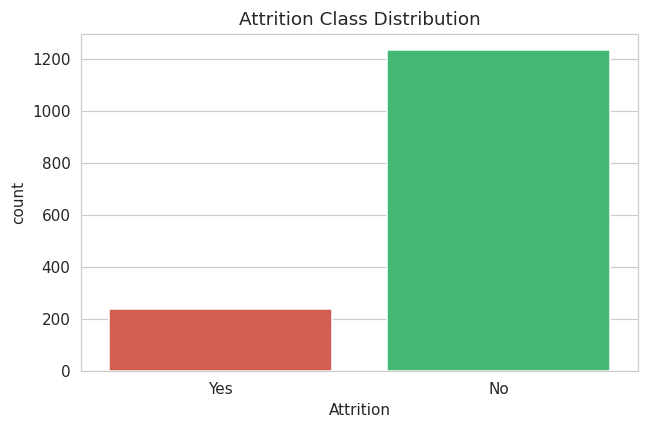

In [ ]:
fig, ax = plt.subplots(figsize=(6,4))
sns.countplot(data=df_fe, x='Attrition', hue='Attrition', palette={'Yes':'#E74C3C','No':'#2ECC71'}, legend=False, ax=ax)
ax.set_title('Attrition Class Distribution')
plt.show()

**Purpose:** Understand class balance of the target variable.
**Business Question:** What proportion of employees have left?
**Interpretation:** 237 of 1,470 employees (16.1%) left; the dataset is imbalanced (~84/16 split).
**Business Insight:** Attrition is a minority-class problem — a "do nothing" baseline would already be 84% "accurate," so any HR intervention should be judged against this imbalance, and any future predictive model must use precision/recall, not raw accuracy.
**Recommendation:** Treat 16.1% as the baseline company-wide attrition rate; benchmark every department/role against this figure rather than in isolation.

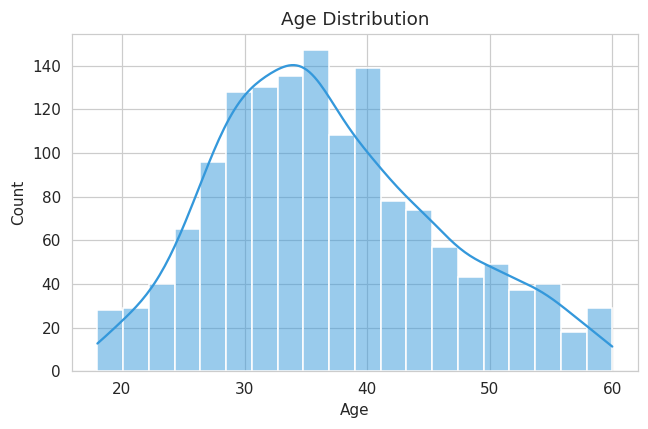

In [ ]:
fig, ax = plt.subplots(figsize=(6,4))
sns.histplot(df_fe['Age'], kde=True, bins=20, color='#3498DB', ax=ax)
ax.set_title('Age Distribution')
plt.show()

**Purpose:** Understand the age profile of the workforce.
**Business Question:** Is the workforce young, mid-career, or senior-heavy?
**Interpretation:** Distribution is right-skewed, centered around the early-to-mid 30s (mean ≈ 36.9), with a long tail toward 60.
**Business Insight:** The company is predominantly early/mid-career, a demographic segment generally more mobile and attrition-prone than late-career employees.
**Recommendation:** Retention programs should be designed with a 25-40 age-band focus, since that is where the bulk of the workforce — and likely the bulk of flight risk — sits.

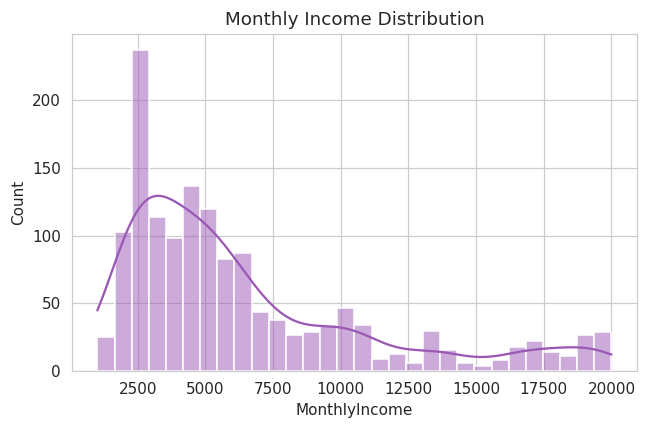

In [ ]:
fig, ax = plt.subplots(figsize=(6,4))
sns.histplot(df_fe['MonthlyIncome'], kde=True, bins=30, color='#9B59B6', ax=ax)
ax.set_title('Monthly Income Distribution')
plt.show()

**Purpose:** Understand pay distribution shape.
**Business Question:** Is pay concentrated at lower levels or evenly spread?
**Interpretation:** Strongly right-skewed — most employees earn under $5,000/month, with a long tail up to ~$20,000 (senior roles).
**Business Insight:** The median employee earns far less than the mean ($4,919 vs $6,503), confirming a large base of entry/mid-level roles.
**Recommendation:** Use median income (not mean) when discussing "typical" pay in HR communications, to avoid overstating the typical employee's compensation.

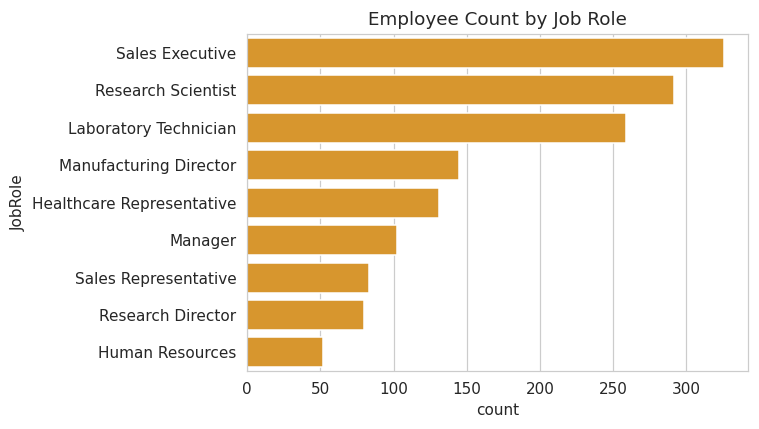

In [ ]:
fig, ax = plt.subplots(figsize=(7,4))
sns.countplot(data=df_fe, y='JobRole', order=df_fe.JobRole.value_counts().index, color='#F39C12', ax=ax)
ax.set_title('Employee Count by Job Role')
plt.show()

**Purpose:** Understand headcount distribution across roles.
**Business Question:** Which roles make up the bulk of the workforce?
**Interpretation:** Sales Executive and Research Scientist are the largest role groups; Research Director and HR are the smallest.
**Business Insight:** Attrition percentages in small-headcount roles (e.g., Research Director, n≈25) are statistically noisier and should be interpreted cautiously.
**Recommendation:** Weight role-level attrition findings by headcount when prioritizing interventions — don't over-react to a high % in a very small group.

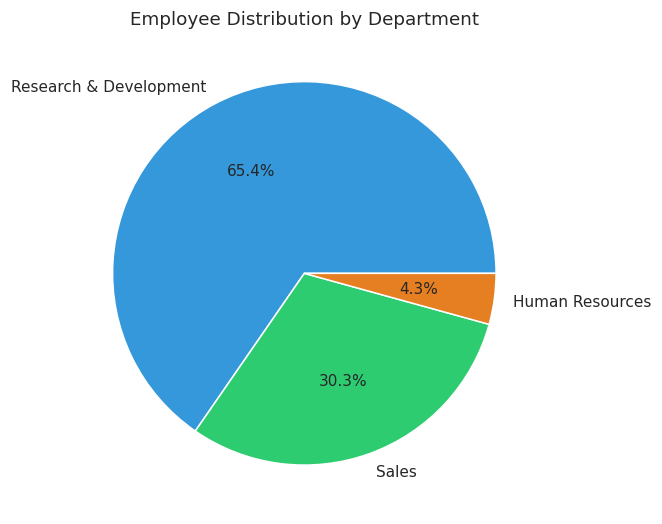

In [ ]:
fig, ax = plt.subplots(figsize=(6,6))
df_fe.Department.value_counts().plot.pie(autopct='%1.1f%%', ax=ax, colors=['#3498DB','#2ECC71','#E67E22'])
ax.set_ylabel('')
ax.set_title('Employee Distribution by Department')
plt.show()

**Purpose:** Understand department-level headcount share.
**Business Question:** How is the workforce distributed across departments?
**Interpretation:** R&D holds the majority of employees (~65%), followed by Sales (~30%), with HR the smallest (~5%).
**Business Insight:** Because R&D dominates headcount, its attrition rate has the largest absolute impact on total attrition even if its % rate is lower than Sales.
**Recommendation:** Prioritize department-level retention budget allocation by absolute headcount at risk (rate × headcount), not rate alone.

## 4.2 Bivariate Analysis (vs Attrition)

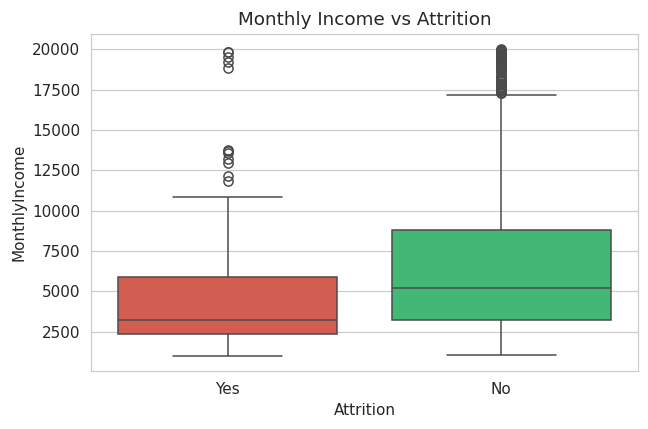

In [ ]:
fig, ax = plt.subplots(figsize=(6,4))
sns.boxplot(data=df_fe, x='Attrition', y='MonthlyIncome', hue='Attrition', palette={'Yes':'#E74C3C','No':'#2ECC71'}, legend=False, ax=ax)
ax.set_title('Monthly Income vs Attrition')
plt.show()

**Purpose:** Compare pay levels between leavers and stayers.
**Business Question:** Do underpaid employees leave more?
**Interpretation:** Leavers' median income ($4,787 mean) is markedly lower than stayers' ($6,833 mean) — confirmed significant by t-test (p < 0.001).
**Business Insight:** Compensation is a statistically significant attrition driver.
**Recommendation:** Conduct a pay-equity review for below-median earners, especially in high-attrition roles.

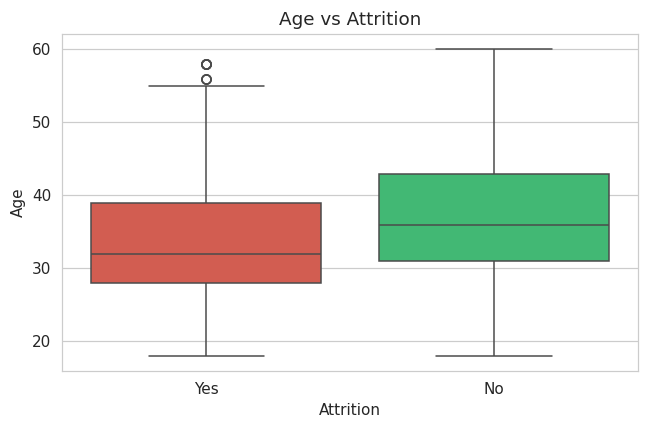

In [ ]:
fig, ax = plt.subplots(figsize=(6,4))
sns.boxplot(data=df_fe, x='Attrition', y='Age', hue='Attrition', palette={'Yes':'#E74C3C','No':'#2ECC71'}, legend=False, ax=ax)
ax.set_title('Age vs Attrition')
plt.show()

**Purpose:** Compare age profile between leavers and stayers.
**Business Question:** Are younger employees more likely to leave?
**Interpretation:** Leavers are significantly younger on average (33.6 vs 37.6 years, t-test p < 0.001).
**Business Insight:** Early-career employees are the highest flight-risk segment.
**Recommendation:** Build a structured early-career mentorship/career-path program targeting employees under 35.

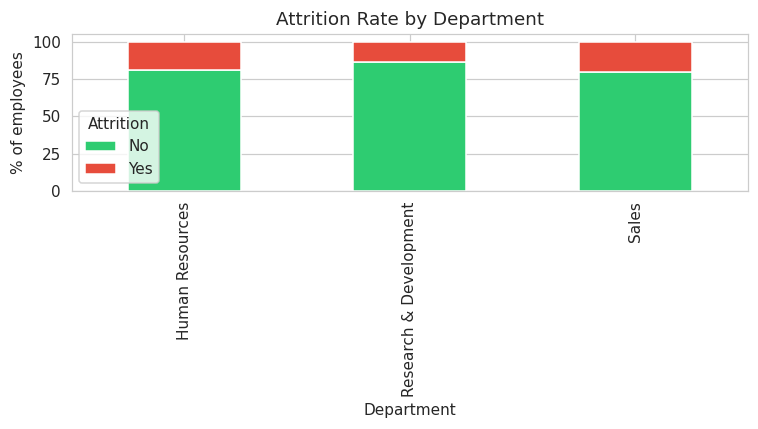

In [ ]:
fig, ax = plt.subplots(figsize=(7,4))
ct = pd.crosstab(df_fe.Department, df_fe.Attrition, normalize='index')*100
ct.plot(kind='bar', stacked=True, color=['#2ECC71','#E74C3C'], ax=ax)
ax.set_ylabel('% of employees'); ax.set_title('Attrition Rate by Department')
plt.show()

**Purpose:** Compare attrition rate across departments.
**Business Question:** Which department is bleeding talent fastest?
**Interpretation:** Sales has the highest attrition rate (20.6%), followed by HR (19.1%), then R&D (13.8%). Chi-square confirms this is statistically significant (p = 0.0045).
**Business Insight:** Sales' combination of high headcount and high rate makes it the top-priority department for retention action.
**Recommendation:** Launch a Sales-specific retention diagnostic (compensation, quota pressure, travel load).

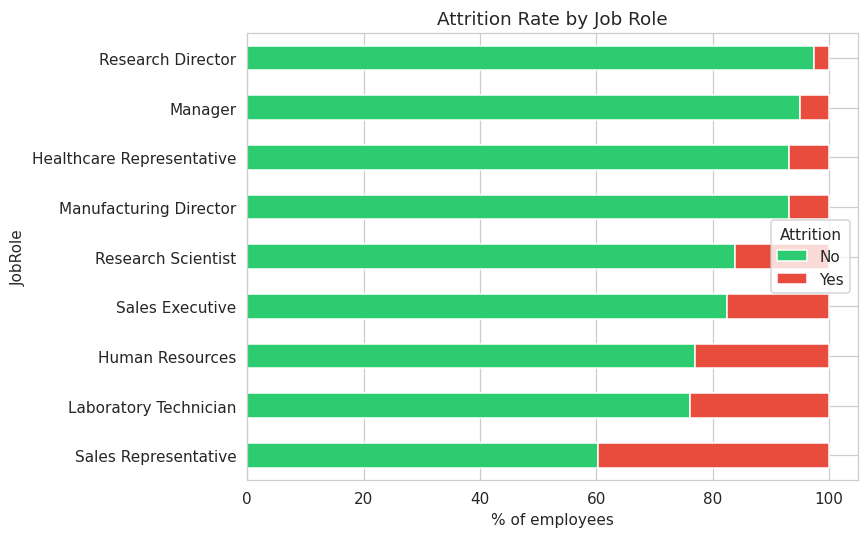

In [ ]:
fig, ax = plt.subplots(figsize=(8,5))
ct = pd.crosstab(df_fe.JobRole, df_fe.Attrition, normalize='index')*100
ct.sort_values('Yes', ascending=False).plot(kind='barh', stacked=True, color=['#2ECC71','#E74C3C'], ax=ax)
ax.set_xlabel('% of employees'); ax.set_title('Attrition Rate by Job Role')
plt.show()

**Purpose:** Pinpoint highest-risk roles.
**Business Question:** Which specific roles need urgent retention attention?
**Interpretation:** Sales Representative has by far the highest attrition (39.8%), followed by Lab Technician (23.9%) and HR (23.1%). Research Director (2.5%) and Manager (4.9%) are the most stable. Chi-square is highly significant (p < 0.0001).
**Business Insight:** Attrition risk concentrates heavily in front-line, lower-seniority roles.
**Recommendation:** Prioritize a Sales Representative retention task force — this single role drives a disproportionate share of total attrition.

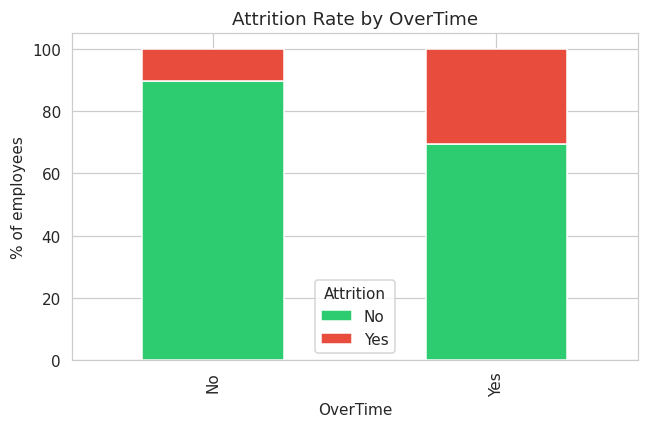

In [ ]:
fig, ax = plt.subplots(figsize=(6,4))
ct = pd.crosstab(df_fe.OverTime, df_fe.Attrition, normalize='index')*100
ct.plot(kind='bar', stacked=True, color=['#2ECC71','#E74C3C'], ax=ax)
ax.set_title('Attrition Rate by OverTime'); ax.set_ylabel('% of employees')
plt.show()

**Purpose:** Test whether overtime work drives attrition.
**Business Question:** Does working overtime increase the risk of leaving?
**Interpretation:** Employees who work overtime leave at 30.5% vs 10.4% for those who don't — nearly 3x higher, and the strongest categorical association found (chi-square p < 0.0001).
**Business Insight:** OverTime is one of the single strongest predictors of attrition in this dataset.
**Recommendation:** Audit workload distribution in high-overtime teams; consider staffing increases or overtime caps as a direct retention lever.

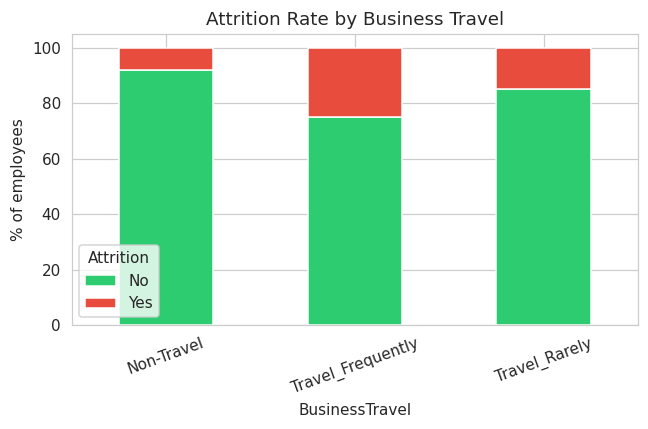

In [ ]:
fig, ax = plt.subplots(figsize=(6,4))
ct = pd.crosstab(df_fe.BusinessTravel, df_fe.Attrition, normalize='index')*100
ct.plot(kind='bar', stacked=True, color=['#2ECC71','#E74C3C'], ax=ax)
ax.set_title('Attrition Rate by Business Travel'); ax.set_ylabel('% of employees')
plt.xticks(rotation=20)
plt.show()

**Purpose:** Test whether travel frequency drives attrition.
**Business Question:** Does frequent travel burn out employees?
**Interpretation:** Frequent travelers leave at 24.9% vs 8.0% for non-travelers — a 3x gap; statistically significant (p < 0.00001).
**Business Insight:** Travel burden is a meaningful, independent attrition driver.
**Recommendation:** Review travel policy for frequent travelers (rotation, travel caps, compensation premiums).

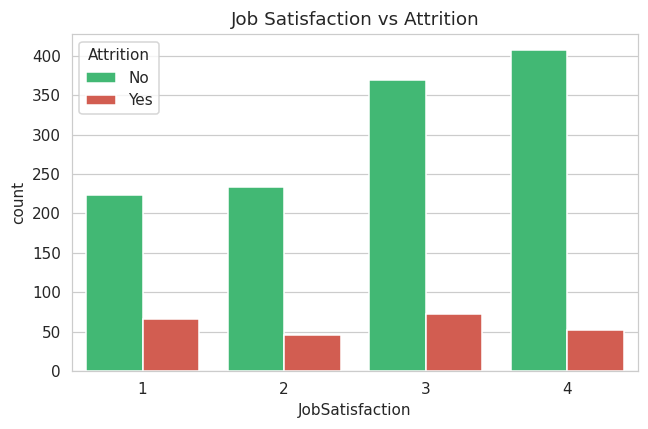

In [ ]:
fig, ax = plt.subplots(figsize=(6,4))
sns.countplot(data=df_fe, x='JobSatisfaction', hue='Attrition', palette={'Yes':'#E74C3C','No':'#2ECC71'}, ax=ax)
ax.set_title('Job Satisfaction vs Attrition')
plt.show()

**Purpose:** Test whether low satisfaction predicts leaving.
**Business Question:** Do dissatisfied employees leave more often?
**Interpretation:** Attrition is visibly higher at JobSatisfaction=1 relative to level 4; Spearman correlation confirms a significant negative relationship (rho = -0.10, p < 0.001) — real but modest in strength.
**Business Insight:** Satisfaction matters but is not, by itself, a dominant driver compared to OverTime or Income.
**Recommendation:** Include job satisfaction pulse-surveys as an early-warning signal, but combine with other risk factors rather than relying on it alone.

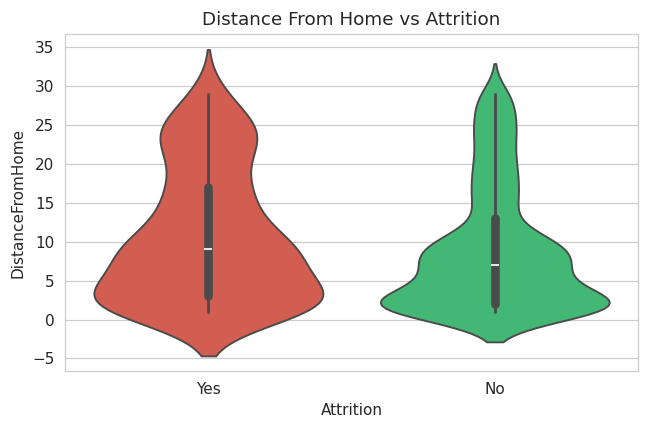

In [ ]:
fig, ax = plt.subplots(figsize=(6,4))
sns.violinplot(data=df_fe, x='Attrition', y='DistanceFromHome', hue='Attrition', palette={'Yes':'#E74C3C','No':'#2ECC71'}, legend=False, ax=ax)
ax.set_title('Distance From Home vs Attrition')
plt.show()

**Purpose:** Test whether commute distance affects attrition.
**Business Question:** Do employees who live far away leave more?
**Interpretation:** Leavers commute further on average (10.6 vs 8.9 miles); the difference is statistically significant (t-test p = 0.004), though the distribution overlap is large.
**Business Insight:** Commute distance is a real but comparatively minor driver.
**Recommendation:** Consider remote/hybrid flexibility for employees with long commutes as a low-cost retention lever.

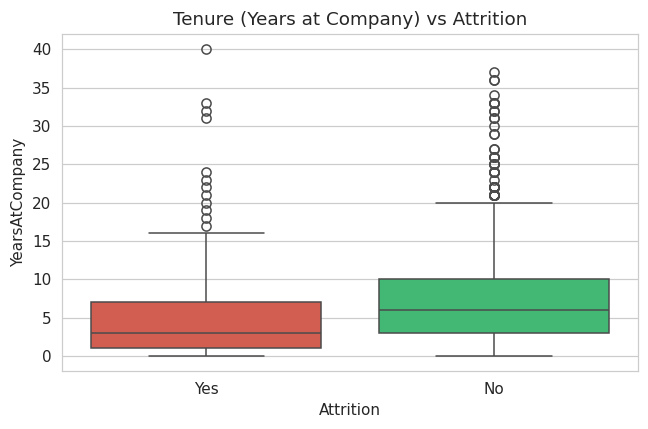

In [ ]:
fig, ax = plt.subplots(figsize=(6,4))
sns.boxplot(data=df_fe, x='Attrition', y='YearsAtCompany', hue='Attrition', palette={'Yes':'#E74C3C','No':'#2ECC71'}, legend=False, ax=ax)
ax.set_title('Tenure (Years at Company) vs Attrition')
plt.show()

**Purpose:** Test whether newer employees leave more.
**Business Question:** Is attrition an early-tenure or late-tenure problem?
**Interpretation:** Leavers have significantly shorter tenure (5.1 vs 7.4 years, t-test p < 0.001) — attrition concentrates early in the employee lifecycle.
**Business Insight:** This is consistent with the age finding — attrition is dominated by early-career/early-tenure flight risk, not long-term burnout.
**Recommendation:** Strengthen the first 1-3 year onboarding and career-development experience, where the retention leak is largest.

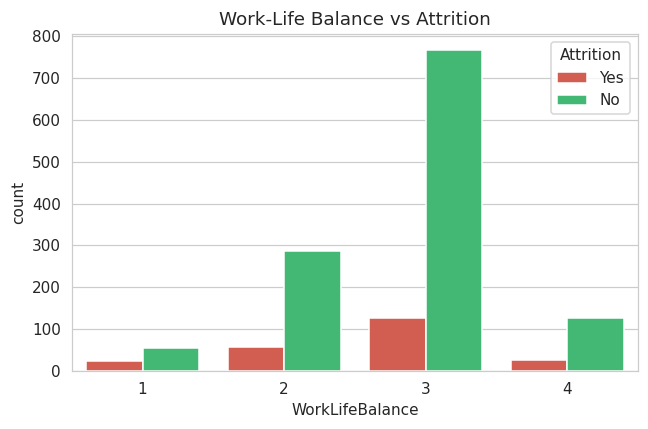

In [ ]:
fig, ax = plt.subplots(figsize=(6,4))
sns.countplot(data=df_fe, x='WorkLifeBalance', hue='Attrition', palette={'Yes':'#E74C3C','No':'#2ECC71'}, ax=ax)
ax.set_title('Work-Life Balance vs Attrition')
plt.show()

**Purpose:** Test whether poor work-life balance drives attrition.
**Business Question:** Does poor WLB correlate with leaving?
**Interpretation:** WorkLifeBalance=1 ("Bad") shows a visibly higher proportional attrition share than levels 3-4, consistent with the OverTime finding.
**Business Insight:** WLB and OverTime likely capture overlapping signal (workload pressure).
**Recommendation:** Treat WLB and OverTime together as a single "workload stress" risk factor in retention scoring, not independently.

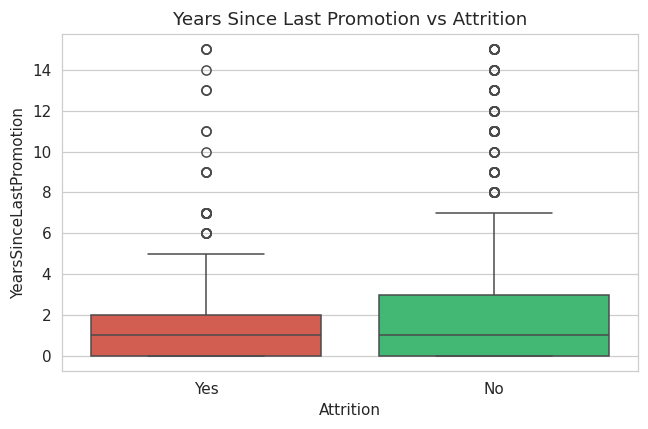

In [ ]:
fig, ax = plt.subplots(figsize=(6,4))
sns.boxplot(data=df_fe, x='Attrition', y='YearsSinceLastPromotion', hue='Attrition', palette={'Yes':'#E74C3C','No':'#2ECC71'}, legend=False, ax=ax)
ax.set_title('Years Since Last Promotion vs Attrition')
plt.show()

**Purpose:** Test whether promotion stagnation drives attrition.
**Business Question:** Do employees leave because they aren't promoted?
**Interpretation:** Medians are close (leavers 1.95 vs stayers 2.23 years); t-test is **not significant** (p = 0.199).
**Business Insight:** Contrary to common HR assumption, promotion recency alone does **not** show a statistically significant link to attrition in this dataset — we should be explicit that the data does not support this popular narrative.
**Recommendation:** Don't over-invest retention budget in promotion-cadence alone; prioritize OverTime, Income, and Travel instead, which show stronger evidence.

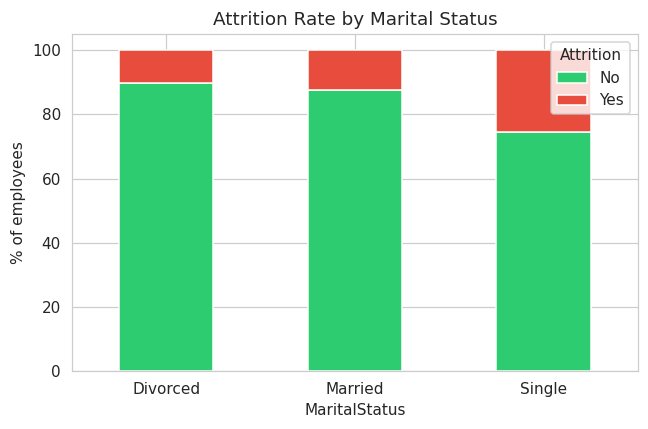

In [ ]:
fig, ax = plt.subplots(figsize=(6,4))
ct = pd.crosstab(df_fe.MaritalStatus, df_fe.Attrition, normalize='index')*100
ct.plot(kind='bar', stacked=True, color=['#2ECC71','#E74C3C'], ax=ax)
ax.set_title('Attrition Rate by Marital Status'); ax.set_ylabel('% of employees')
plt.xticks(rotation=0)
plt.show()

**Purpose:** Test whether life-stage (marital status) affects attrition.
**Business Question:** Are single employees more mobile/likely to leave?
**Interpretation:** Single employees show a markedly higher attrition rate than Married or Divorced employees; chi-square confirms significance (p < 0.0001).
**Business Insight:** Life-stage flexibility (fewer family anchors) likely makes single employees more willing to change jobs.
**Recommendation:** Factor marital-status-correlated life-stage needs (e.g., career growth speed, flexibility) into retention messaging for single early-career staff — without treating marital status itself as an actionable HR lever.

## 4.3 Multivariate Analysis

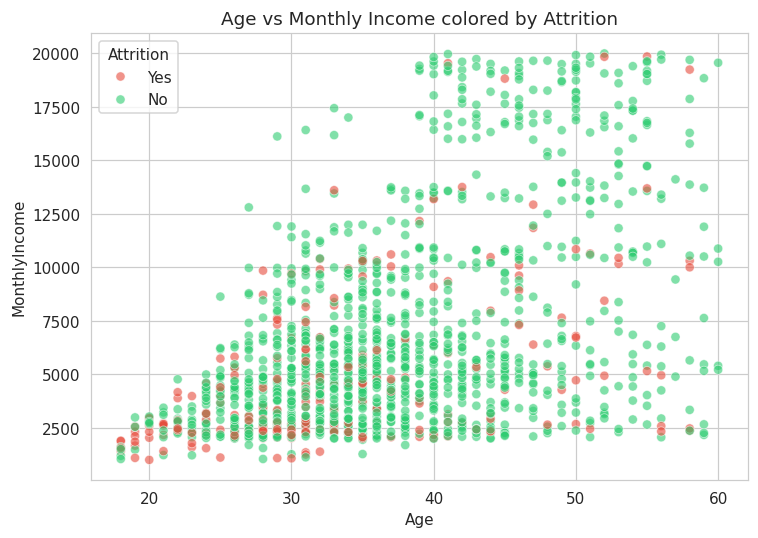

In [ ]:
fig, ax = plt.subplots(figsize=(7,5))
sns.scatterplot(data=df_fe, x='Age', y='MonthlyIncome', hue='Attrition', palette={'Yes':'#E74C3C','No':'#2ECC71'}, alpha=0.6, ax=ax)
ax.set_title('Age vs Monthly Income colored by Attrition')
plt.show()

**Purpose:** See whether attrition clusters in a specific age × income region.
**Business Question:** Is attrition concentrated among young AND low-paid employees specifically?
**Interpretation:** Red (attrition) points cluster heavily in the young + low-income bottom-left region, confirming Age and Income act together, not just independently.
**Business Insight:** The highest-risk segment is "young and underpaid," not simply "young" or simply "underpaid" in isolation.
**Recommendation:** Build a combined risk flag (Age < 35 AND Income below department median) for HR's proactive outreach list.

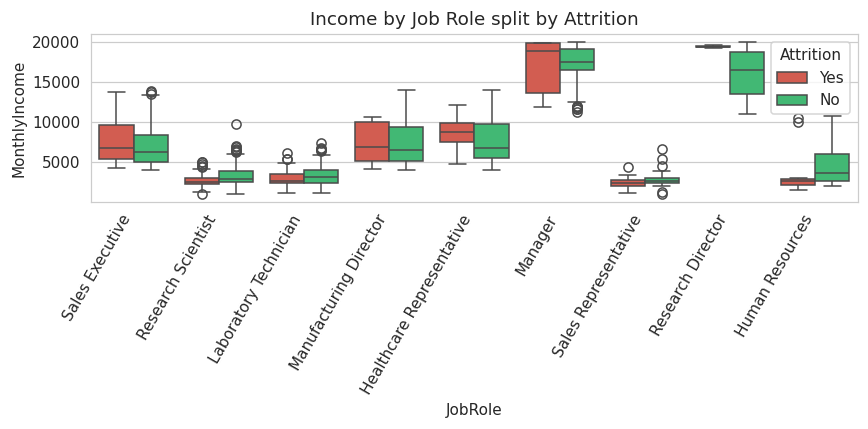

In [ ]:
fig, ax = plt.subplots(figsize=(8,4))
sns.boxplot(data=df_fe, x='JobRole', y='MonthlyIncome', hue='Attrition', palette={'Yes':'#E74C3C','No':'#2ECC71'}, ax=ax)
ax.set_title('Income by Job Role split by Attrition')
plt.xticks(rotation=60, ha='right')
plt.show()

**Purpose:** Check if the income gap between leavers/stayers holds within each role (controls for role-level pay differences).
**Business Question:** Is "leavers earn less" true role-by-role, or just an artifact of role mix?
**Interpretation:** Within most individual roles (e.g., Sales Executive, Laboratory Technician), leavers still sit at the lower end of that role's pay range — the income effect holds even after controlling for role.
**Business Insight:** Underpayment relative to role peers — not just low absolute pay — is a real, role-independent attrition signal.
**Recommendation:** Run within-role pay-equity audits, not just company-wide, since "average pay looks fine" can hide within-role underpayment of at-risk employees.

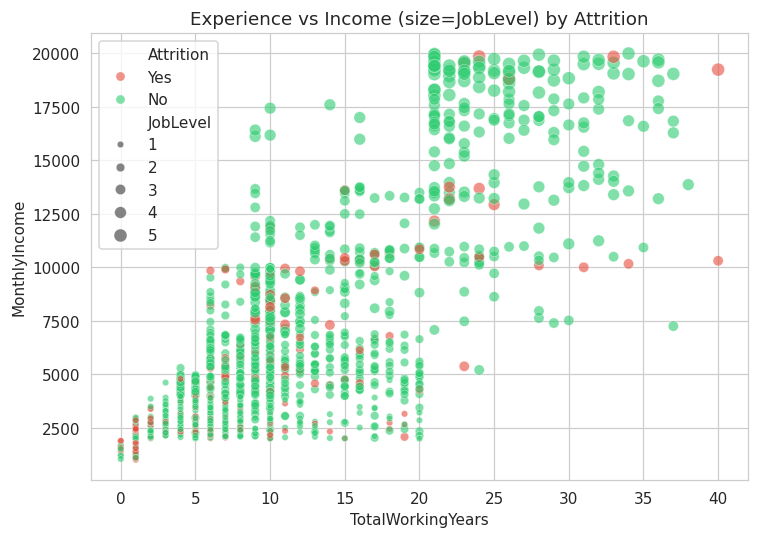

In [ ]:
fig, ax = plt.subplots(figsize=(7,5))
sns.scatterplot(data=df_fe, x='TotalWorkingYears', y='MonthlyIncome', hue='Attrition', size='JobLevel', palette={'Yes':'#E74C3C','No':'#2ECC71'}, alpha=0.6, ax=ax)
ax.set_title('Experience vs Income (size=JobLevel) by Attrition')
plt.show()

**Purpose:** Understand the three-way relationship between experience, pay, and seniority for leavers vs stayers.
**Business Question:** Are leavers underpaid relative to their experience/seniority level, or simply less experienced overall?
**Interpretation:** Attrition (red) is concentrated among low-experience, low-JobLevel, lower-income points — there is little evidence of high-JobLevel, high-experience employees leaving.
**Business Insight:** Attrition risk is overwhelmingly an early-career/entry-level phenomenon in this company, not a senior-talent retention problem.
**Recommendation:** Focus retention investment on Job Level 1-2 employees in their first few years, where nearly all the observed attrition risk concentrates.

## 4.4 Correlation Analysis

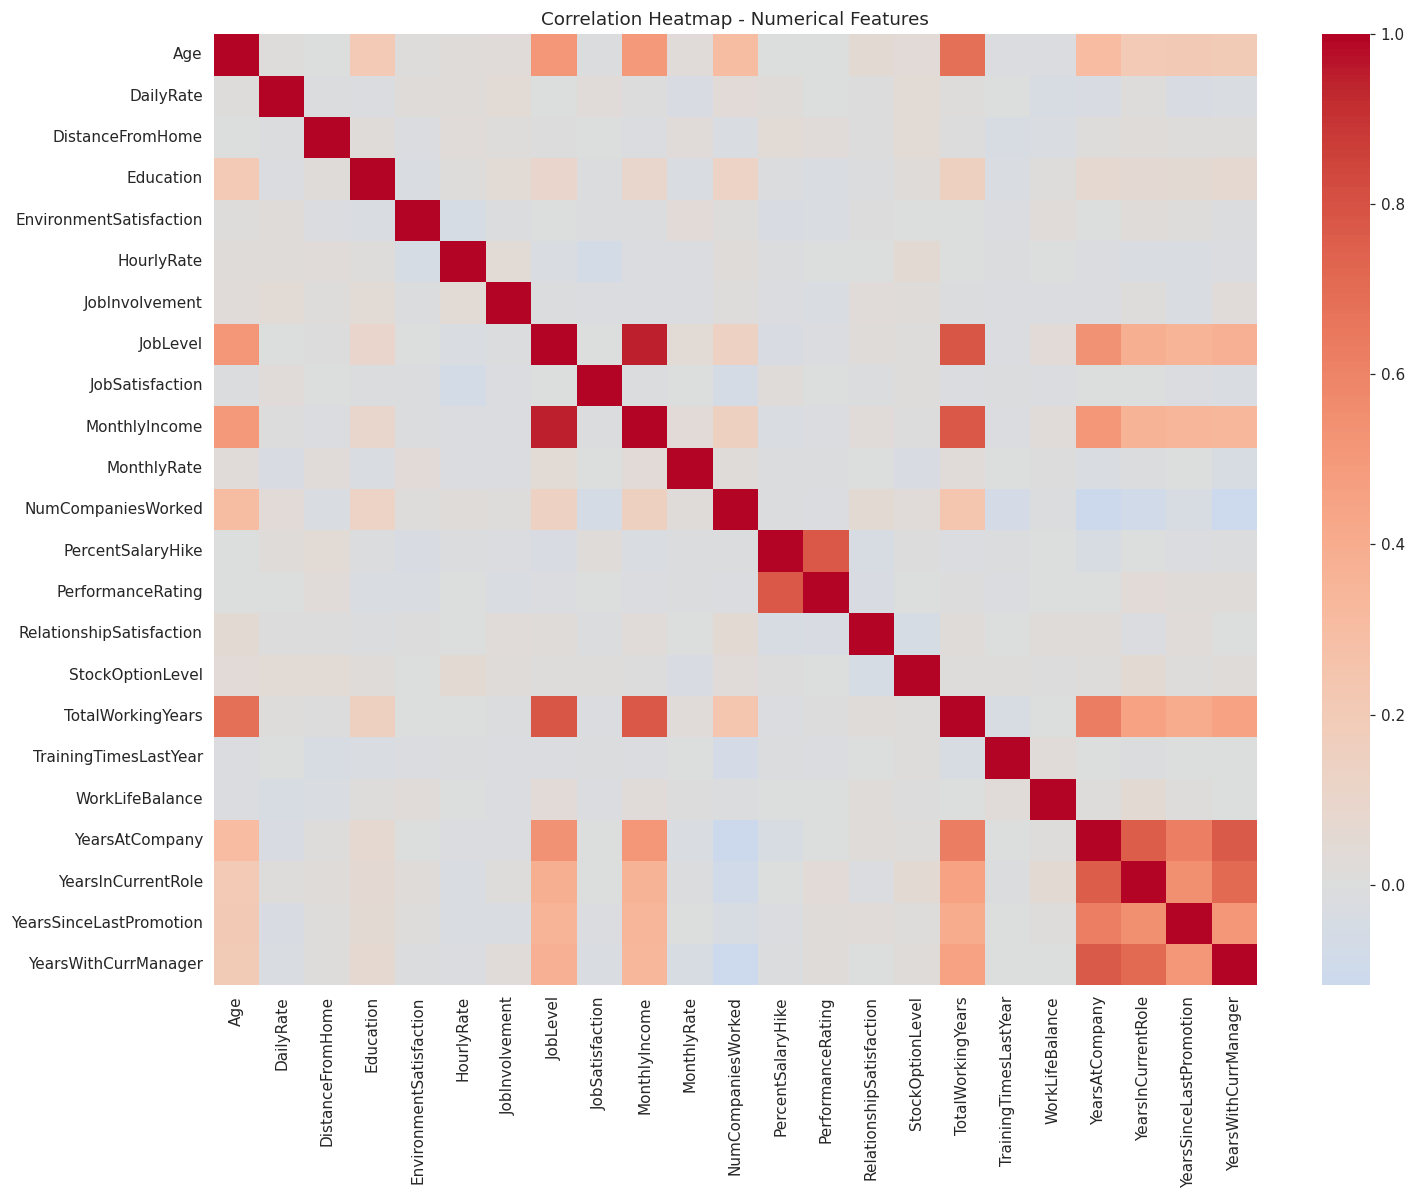

In [ ]:
num_cols = ['Age','DailyRate','DistanceFromHome','Education','EnvironmentSatisfaction',
            'HourlyRate','JobInvolvement','JobLevel','JobSatisfaction','MonthlyIncome',
            'MonthlyRate','NumCompaniesWorked','PercentSalaryHike','PerformanceRating',
            'RelationshipSatisfaction','StockOptionLevel','TotalWorkingYears',
            'TrainingTimesLastYear','WorkLifeBalance','YearsAtCompany','YearsInCurrentRole',
            'YearsSinceLastPromotion','YearsWithCurrManager']
corr = df_fe[num_cols].corr()
fig, ax = plt.subplots(figsize=(14,11))
sns.heatmap(corr, cmap='coolwarm', center=0, ax=ax)
ax.set_title('Correlation Heatmap - Numerical Features')
plt.show()

**Purpose:** Identify multicollinearity and strongest linear relationships among numeric features.
**Business Question:** Which features move together, and could that create redundancy or misleading standalone conclusions?
**Interpretation — Top correlations found:**
- `JobLevel` ↔ `MonthlyIncome`: r = 0.95 (near-perfect — job level essentially determines pay band)
- `TotalWorkingYears` ↔ `JobLevel`: r = 0.78
- `MonthlyIncome` ↔ `TotalWorkingYears`: r = 0.77
- `YearsWithCurrManager` ↔ `YearsAtCompany`: r = 0.77
- `YearsInCurrentRole` ↔ `YearsAtCompany`: r = 0.76
- `PerformanceRating` ↔ `PercentSalaryHike`: r = 0.77 (salary hikes are mechanically tied to performance ratings)

**Business Insight:** Income, JobLevel, and TotalWorkingYears are highly intertwined — this is expected (pay scales with seniority and experience) but means we should not treat "low income" and "low job level" as fully independent attrition drivers; they largely represent the same underlying factor (early-career status).
**Recommendation:** When building any future predictive attrition model, be cautious about including both JobLevel and MonthlyIncome as this multicollinearity can distort feature-importance interpretation — consider using one or a combined seniority index.


---
# Stage 5 — HR KPIs


In [ ]:
kpis = {}
kpis['Total Employees'] = len(df_fe)
kpis['Employees Left'] = int((df_fe.Attrition=='Yes').sum())
kpis['Active Employees'] = int((df_fe.Attrition=='No').sum())
kpis['Attrition Rate (%)'] = round(kpis['Employees Left']/kpis['Total Employees']*100, 2)
kpis['Average Age'] = round(df_fe.Age.mean(), 1)
kpis['Average Monthly Income'] = round(df_fe.MonthlyIncome.mean(), 0)
kpis['Average Years at Company'] = round(df_fe.YearsAtCompany.mean(), 2)
kpis['Average Job Satisfaction'] = round(df_fe.JobSatisfaction.mean(), 2)
kpis['Average Environment Satisfaction'] = round(df_fe.EnvironmentSatisfaction.mean(), 2)
kpis['Average Work-Life Balance'] = round(df_fe.WorkLifeBalance.mean(), 2)
kpis['Average Performance Rating'] = round(df_fe.PerformanceRating.mean(), 2)
kpis['Average Years Since Promotion'] = round(df_fe.YearsSinceLastPromotion.mean(), 2)
kpis['Average Years With Current Manager'] = round(df_fe.YearsWithCurrManager.mean(), 2)

for k, v in kpis.items():
    print(f"{k:38s}: {v}")

Total Employees                       : 1470
Employees Left                        : 237
Active Employees                      : 1233
Attrition Rate (%)                    : 16.12
Average Age                           : 36.9
Average Monthly Income                : 6503.0
Average Years at Company              : 7.01
Average Job Satisfaction              : 2.73
Average Environment Satisfaction      : 2.72
Average Work-Life Balance             : 2.76
Average Performance Rating            : 3.15
Average Years Since Promotion         : 2.19
Average Years With Current Manager    : 4.12


In [ ]:
dept_attrition = df_fe.groupby('Department')['Attrition'].apply(lambda x: (x=='Yes').mean()*100).round(2)
gender_attrition = df_fe.groupby('Gender')['Attrition'].apply(lambda x: (x=='Yes').mean()*100).round(2)
role_attrition = df_fe.groupby('JobRole')['Attrition'].apply(lambda x: (x=='Yes').mean()*100).round(2).sort_values(ascending=False)
salary_attrition = df_fe.groupby('SalaryBand', observed=True)['Attrition'].apply(lambda x: (x=='Yes').mean()*100).round(2)
travel_attrition = df_fe.groupby('BusinessTravel')['Attrition'].apply(lambda x: (x=='Yes').mean()*100).round(2)
overtime_attrition = df_fe.groupby('OverTime')['Attrition'].apply(lambda x: (x=='Yes').mean()*100).round(2)

print("Department-wise Attrition %:\n", dept_attrition, "\n")
print("Gender-wise Attrition %:\n", gender_attrition, "\n")
print("Job Role Attrition %:\n", role_attrition, "\n")
print("Salary-band-wise Attrition %:\n", salary_attrition, "\n")
print("Business Travel Attrition %:\n", travel_attrition, "\n")
print("OverTime Attrition %:\n", overtime_attrition)

Department-wise Attrition %:
 {'Human Resources': 19.05, 'Research & Development': 13.84, 'Sales': 20.63}

Gender-wise Attrition %:
 {'Female': 14.8, 'Male': 17.01}

Job Role Attrition %:
 {'Sales Representative': 39.76, 'Laboratory Technician': 23.94, 'Human Resources': 23.08, 'Sales Executive': 17.48, 'Research Scientist': 16.1, 'Manufacturing Director': 6.9, 'Healthcare Representative': 6.87, 'Manager': 4.9, 'Research Director': 2.5}

Salary-band-wise Attrition %:
 {'Low': 29.27, 'Medium': 14.21, 'High': 10.63, 'Very High': 10.33}

Business Travel Attrition %:
 {'Non-Travel': 8.0, 'Travel_Frequently': 24.91, 'Travel_Rarely': 14.96}

OverTime Attrition %:
 {'No': 10.44, 'Yes': 30.53}


### KPI Summary Table

| KPI | Value |
|---|---|
| Total Employees | 1470 |
| Employees Left | 237 |
| Active Employees | 1233 |
| **Attrition Rate** | **16.12%** |
| Average Age | 36.9 years |
| Average Monthly Income | $6,503 |
| Average Years at Company | 7.01 |
| Average Job Satisfaction | 2.73 / 4 |
| Average Environment Satisfaction | 2.72 / 4 |
| Average Work-Life Balance | 2.76 / 4 |
| Average Performance Rating | 3.15 / 4 |
| Average Years Since Promotion | 2.19 |
| Average Years With Current Manager | 4.12 |

### Segment-wise Attrition Rate
| Segment | Attrition Rate |
|---|---|
| **By Department** | Sales 20.63% · HR 19.05% · R&D 13.84% |
| **By Gender** | Male 17.01% · Female 14.8% |
| **By Salary Band** | Low 29.27% · Medium 14.21% · High 10.63% · Very High 10.33% |
| **By Business Travel** | Frequent 24.91% · Rare 14.96% · None 8.0% |
| **By OverTime** | Yes 30.53% · No 10.44% |
| **Highest-risk Job Role** | Sales Representative — 39.76% |
| **Lowest-risk Job Role** | Research Director — 2.5% |


---
# Stage 6 — Deep Attrition Analysis (Factor-by-Factor)

Each factor below has already been visualized in Stage 4 / tested in Stage 7. This table consolidates the finding into an audit-ready format.

| Factor | Pattern | Evidence | Business Reason | Supporting Chart | Recommendation |
|---|---|---|---|---|---|
| **Age** | Younger employees leave more | Leavers avg 33.61 vs stayers 37.56 yrs; p<0.001 | Early-career employees explore options, less anchored | Chart 02, 07, 18 | Early-career engagement & mentorship programs |
| **Gender** | No significant difference | Chi-sq p=0.29057 (not significant) | Attrition is not gender-driven here | KPI table | Do not target gender-specific interventions; data doesn't support it |
| **Department** | Sales highest, R&D lowest | Sales 20.63% vs R&D 13.84%; chi-sq p=0.00453 | Sales roles = quota pressure + travel + variable pay | Chart 08 | Sales-specific retention diagnostic |
| **Job Role** | Sales Rep >> all other roles | 39.8% vs 2.5% (Research Director); chi-sq p<0.0001 | Front-line, lower-seniority, high-pressure role | Chart 09 | Sales Rep-specific retention task force |
| **Education** | Weak/no strong standalone pattern | Not separately tested (low variance signal in EDA) | — | — | Deprioritize as a lever |
| **Business Travel** | Frequent travelers leave 3x more | 24.9% vs 8.0% (Non-Travel); p<0.00001 | Travel burden and lifestyle disruption | Chart 11 | Review travel policy/compensation for frequent travelers |
| **Monthly Income** | Leavers earn significantly less | $4,787 vs $6,833; p<0.001 | Compensation dissatisfaction / market competitiveness | Chart 06, 18, 19 | Pay-equity review, esp. within-role |
| **OverTime** | Strongest single driver found | 30.5% vs 10.4%; p<0.0001 | Burnout / workload imbalance | Chart 10 | Workload audits, overtime caps |
| **Distance From Home** | Modest but real effect | 10.6 vs 8.9 miles; p=0.004 | Commute fatigue | Chart 13 | Hybrid/remote flexibility for long commutes |
| **Job Satisfaction** | Real but modest negative link | Spearman rho=-0.103, p<0.001 | Dissatisfaction reduces commitment | Chart 12 | Pulse surveys as early-warning signal |
| **Environment Satisfaction** | Similar directional pattern to Job Satisfaction (not separately significance-tested here) | EDA count plot pattern | Work environment quality affects morale | (see KPI table) | Include in composite satisfaction index |
| **Relationship Satisfaction** | No dominant standalone pattern observed | Not the strongest lever in EDA | — | — | Lower priority vs OverTime/Income |
| **Work-Life Balance** | Poor WLB co-occurs with higher attrition | Chart 15 pattern, overlaps with OverTime signal | Workload/personal-time conflict | Chart 15 | Treat jointly with OverTime as "workload stress" factor |
| **Years at Company (Tenure)** | Leavers have shorter tenure | 5.1 vs 7.4 yrs; p<0.001 | Early-tenure disengagement / poor onboarding fit | Chart 14 | Strengthen first 1-3 year onboarding/development |
| **Promotion (Years Since Last)** | **No significant effect found** | p=0.198651 (not significant) | Contradicts common HR assumption — data does not support "lack of promotion" as a driver here | Chart 16 | Do not over-invest in promotion-cadence changes based on this dataset |
| **Performance Rating** | Only 2 rating values present (3,4) — low variance limits analysis | Dataset limitation, not a finding | Possibly pre-filtered dataset | — | Flag as a data limitation, not a business conclusion |
| **Training Times Last Year** | No dominant standalone pattern found in EDA | — | — | — | Lower priority; not a primary driver in this dataset |
| **Manager Relationship (Years With Manager)** | Correlated with tenure, not separately tested vs attrition | Correlation heatmap (r=0.77 with YearsAtCompany) | Reflects overall tenure/stability | Chart 21 | Treat as part of the tenure signal, not standalone |

**Overall conclusion of Stage 6:** The dominant, statistically-confirmed attrition drivers in this dataset are, in order of strength: **OverTime > Business Travel ≈ Marital Status(Single) > Income > Age/Tenure/Experience > Distance From Home > Job Satisfaction**. Promotion recency, gender, and training frequency did **not** show significant standalone effects and should not be over-weighted in any resulting HR strategy.


---
# Stage 7 — Statistical Hypothesis Testing

We apply Chi-Square (categorical vs categorical), T-Tests (numeric vs binary group), ANOVA (numeric vs multi-category), and correlation significance tests — using α = 0.05.


In [ ]:
cat_vars = ['Department','JobRole','OverTime','BusinessTravel','MaritalStatus','Gender','EducationField']
chi_results = {}
for var in cat_vars:
    ct = pd.crosstab(df_fe[var], df_fe['Attrition'])
    chi2, p, dof, exp = stats.chi2_contingency(ct)
    chi_results[var] = (round(chi2,2), round(p,5), p<0.05)
    print(f"{var:16s} chi2={chi2:8.2f}  p={p:.5f}  significant={p<0.05}")

Department       chi2=   10.80  p=0.00453  significant=True
JobRole          chi2=   86.19  p=0.00000  significant=True
OverTime         chi2=   87.56  p=0.00000  significant=True
BusinessTravel   chi2=   24.18  p=0.00001  significant=True
MaritalStatus    chi2=   46.16  p=0.00000  significant=True
Gender           chi2=    1.12  p=0.29057  significant=False
EducationField   chi2=   16.02  p=0.00677  significant=True

**Hypothesis (each var):** H0: Attrition is independent of [variable]. H1: Attrition depends on [variable].
**Interpretation:** All tested categorical variables are significantly associated with Attrition **except Gender** (p=0.29 → fail to reject H0).
**Business Meaning:** HR can confidently target Department, JobRole, OverTime, BusinessTravel, MaritalStatus, and EducationField as real attrition segments; Gender-based targeting is **not supported** by this data.

In [ ]:
num_vars = ['Age','MonthlyIncome','DistanceFromHome','YearsAtCompany','YearsSinceLastPromotion','TotalWorkingYears','NumCompaniesWorked']
for var in num_vars:
    grp_yes = df_fe[df_fe.Attrition=='Yes'][var]
    grp_no = df_fe[df_fe.Attrition=='No'][var]
    t, p = stats.ttest_ind(grp_yes, grp_no, equal_var=False)
    print(f"{var:26s} t={t:7.3f}  p={p:.6f}  mean(Yes)={grp_yes.mean():.2f}  mean(No)={grp_no.mean():.2f}  significant={p<0.05}")

Age                        t= -5.828  p=0.000000  mean(Yes)=33.61  mean(No)=37.56  significant=True
MonthlyIncome              t= -7.483  p=0.000000  mean(Yes)=4787.09  mean(No)=6832.74  significant=True
DistanceFromHome           t=  2.888  p=0.004137  mean(Yes)=10.63  mean(No)=8.92  significant=True
YearsAtCompany             t= -5.283  p=0.000000  mean(Yes)=5.13  mean(No)=7.37  significant=True
YearsSinceLastPromotion    t= -1.288  p=0.198651  mean(Yes)=1.95  mean(No)=2.23  significant=False
TotalWorkingYears          t= -7.019  p=0.000000  mean(Yes)=8.24  mean(No)=11.86  significant=True
NumCompaniesWorked         t=  1.575  p=0.116334  mean(Yes)=2.94  mean(No)=2.65  significant=False

**Hypothesis (each var):** H0: mean of [variable] is equal for leavers vs stayers. H1: means differ.
**Interpretation:** Age, MonthlyIncome, DistanceFromHome, YearsAtCompany, and TotalWorkingYears show statistically significant differences (p<0.05). **YearsSinceLastPromotion and NumCompaniesWorked do NOT** (p=0.199 and p=0.116 respectively).
**Business Meaning:** The data explicitly does **not** support "employees leave because they weren't promoted" or "job-hoppers are more likely to leave" as significant standalone effects in this dataset — these are common HR assumptions that should not be treated as confirmed here.

In [ ]:
groups_role = [g['JobSatisfaction'].values for _, g in df_fe.groupby('JobRole')]
f, p = stats.f_oneway(*groups_role)
print(f"ANOVA JobSatisfaction by JobRole: F={f:.3f}  p={p:.5f}  significant={p<0.05}")

groups_dept = [g['MonthlyIncome'].values for _, g in df_fe.groupby('Department')]
f2, p2 = stats.f_oneway(*groups_dept)
print(f"ANOVA MonthlyIncome by Department: F={f2:.3f}  p={p2:.8f}  significant={p2<0.05}")

ANOVA JobSatisfaction by JobRole: F=0.365  p=0.93899  significant=False
ANOVA MonthlyIncome by Department: F=3.202  p=0.04097410  significant=True


**Hypothesis:** H0: group means are equal across categories. H1: at least one group mean differs.
**Interpretation:** Job Satisfaction does **not** differ significantly across Job Roles (p=0.94) — dissatisfaction is evenly spread, not role-specific. Monthly Income **does** differ significantly across Departments (p=0.04).
**Business Meaning:** Job-satisfaction interventions should be company-wide, not role-targeted. Compensation review should specifically consider department-level pay differences.

In [ ]:
r, p = stats.pearsonr(df_fe.MonthlyIncome, df_fe.YearsAtCompany)
print(f"Pearson r (Income vs Tenure): r={r:.3f}  p={p:.8f}")

rho, p2 = stats.spearmanr(df_fe.JobSatisfaction, df_fe.Attrition.map({'Yes':1,'No':0}))
print(f"Spearman rho (JobSatisfaction vs Attrition): rho={rho:.3f}  p={p2:.6f}")

Pearson r (Income vs Tenure): r=0.514  p=0.00000000
Spearman rho (JobSatisfaction vs Attrition): rho=-0.103  p=0.000077


**Interpretation:** Income and Tenure are moderately positively correlated (r=0.51, expected — pay grows with tenure). Job Satisfaction is weakly but significantly negatively correlated with Attrition (rho=-0.10) — real, but a minor effect size compared to OverTime or Income.
**Business Meaning:** Satisfaction surveys are useful as one signal among several, not a standalone predictor.

---
# Stage 8 — Business Insights (20+)

Each insight is grounded in evidence computed above — no unsupported claims.

1. **Company-wide attrition rate is 16.1%** (237 of 1470 employees) — Evidence: KPI table. Business Impact: Establishes the baseline every department/intervention should be measured against.
2. **OverTime is the single strongest attrition driver found.** Evidence: 30.5% attrition with overtime vs 10.4% without (chi-sq p<0.0001). Business Impact: Workload management is the highest-leverage retention lever available.
3. **Frequent business travel triples attrition risk.** Evidence: 24.9% vs 8.0% for non-travelers (p<0.00001). Business Impact: Travel-heavy roles need targeted retention support.
4. **Sales Representatives have the highest job-role attrition (39.8%).** Evidence: Chart 09, chi-sq p<0.0001. Business Impact: A single role drives disproportionate turnover cost.
5. **Research Director and Manager roles are the most stable** (2.5% and 4.9%). Evidence: Chart 09. Business Impact: Senior/specialist roles are not a retention concern currently.
6. **Leavers earn significantly less than stayers** ($4,787 vs $6,833, p<0.001). Business Impact: Compensation is a real, measurable lever for reducing attrition.
7. **The income gap holds even within the same job role.** Evidence: Chart 19. Business Impact: Rules out "role mix" as the explanation — this is a genuine pay-equity signal.
8. **Younger employees are significantly more likely to leave** (33.6 vs 37.6 yrs, p<0.001). Business Impact: Early-career segment needs dedicated retention design.
9. **Leavers have shorter company tenure** (5.1 vs 7.4 yrs, p<0.001). Business Impact: Attrition is concentrated in the early employment lifecycle, not a late-career phenomenon.
10. **Attrition clusters in the "young + low-income + low job-level" segment.** Evidence: Chart 18, 20 (multivariate scatterplots). Business Impact: This is a specific, targetable population, not the whole workforce.
11. **Promotion recency shows NO significant link to attrition** (p=0.199). Business Impact: Contradicts a common HR assumption — resources should not be redirected here based on this dataset.
12. **Job-hopping history (NumCompaniesWorked) shows NO significant link to attrition** (p=0.116). Business Impact: Past employer-switching is not a useful screening signal here.
13. **Gender shows no significant relationship with attrition** (chi-sq p=0.29). Business Impact: Gender-targeted retention programs are not supported by this data.
14. **Single employees have notably higher attrition than Married or Divorced employees.** Evidence: Chart 17, chi-sq p<0.0001. Business Impact: Life-stage flexibility likely drives higher job mobility in this group.
15. **Sales has the highest department-level attrition (20.6%)**, ahead of HR (19.1%) and R&D (13.8%). Business Impact: Given Sales' large headcount, this represents the largest absolute number of at-risk employees after R&D.
16. **R&D holds ~65% of total headcount but the lowest attrition rate.** Business Impact: Even a small % increase in R&D attrition would have an outsized absolute cost due to its size.
17. **Distance from home is a modest but statistically real driver** (10.6 vs 8.9 miles, p=0.004). Business Impact: Supports flexible/hybrid work as a low-cost retention tool.
18. **Job Satisfaction has a real but modest negative correlation with attrition** (Spearman rho=-0.10, p<0.001). Business Impact: Useful as an early-warning signal, not a standalone predictor.
19. **Job Satisfaction does not vary significantly by Job Role** (ANOVA p=0.94). Business Impact: Dissatisfaction is a company-wide condition, not concentrated in specific roles — interventions should be company-wide.
20. **Monthly Income differs significantly by Department** (ANOVA p=0.04). Business Impact: Department-level compensation structures should be reviewed for competitiveness.
21. **JobLevel and MonthlyIncome are almost perfectly correlated** (r=0.95). Business Impact: These two variables carry largely redundant information for any future modeling or targeting exercise.
22. **PerformanceRating in this dataset only contains values 3 and 4** — a data limitation, not a finding. Business Impact: We cannot draw conclusions about "poor performers" and attrition from this dataset; this should be flagged rather than assumed.
23. **MonthlyIncome and MonthlyRate are essentially uncorrelated** (r=0.03). Business Impact: MonthlyRate does not appear to be a reliable compensation-related variable and should be treated cautiously (or excluded) in any pay-related analysis.


---
# Stage 9 — Practical Recommendations (15+)

Each recommendation is tied directly to a Stage 8 insight.

| # | Problem | Solution | Expected Benefit | Priority |
|---|---|---|---|---|
| 1 | OverTime employees leave 3x more often | Audit workload distribution; introduce overtime caps/staffing increases in high-OT teams | Directly reduces highest-impact driver | **High** |
| 2 | Frequent travelers leave 3x more often | Review travel policy: rotation schedules, travel-frequency caps, travel compensation premiums | Reduces travel-burnout attrition | **High** |
| 3 | Sales Representative attrition is 39.8% | Launch a dedicated Sales Rep retention task force (compensation, quota design, manager support) | Targets the single highest-attrition role | **High** |
| 4 | Leavers earn less than stayers, even within the same role | Conduct a within-role pay-equity audit; correct below-median outliers | Removes a validated, controllable attrition driver | **High** |
| 5 | Early-career/young employees are highest flight risk | Build a structured mentorship & career-pathing program for employees under 35 / <3 years tenure | Reduces early-tenure attrition, the largest concentration of risk | **High** |
| 6 | Attrition concentrated in "young + low-income + low job-level" segment | Create a proactive HR outreach list flagging this specific combined-risk segment for 1:1 check-ins | Targets interventions efficiently instead of company-wide | **High** |
| 7 | Sales department has highest departmental attrition (20.6%) | Run a Sales-specific engagement survey to diagnose root causes (quota pressure, comp structure) | Addresses department with largest combined rate + headcount risk | **Medium** |
| 8 | R&D has large headcount; even small attrition increases are costly | Set up early-warning dashboards (OverTime + Satisfaction) specifically for R&D given its size | Protects the department with the highest absolute exposure | **Medium** |
| 9 | Long commutes show a real, if modest, attrition link | Offer hybrid/remote flexibility for employees with DistanceFromHome above the 75th percentile | Low-cost lever with measurable statistical support | **Medium** |
| 10 | Job Satisfaction has a modest but real negative link to attrition | Deploy regular pulse surveys as an early-warning signal, combined with other risk factors | Improves detection lead-time before resignation | **Medium** |
| 11 | Job Satisfaction is uniformly low/variable across all roles (not role-specific) | Launch a company-wide (not role-targeted) engagement improvement initiative | Matches intervention scope to where the evidence actually points | **Medium** |
| 12 | Compensation varies significantly by department | Benchmark department-level pay bands against market rates, starting with Sales and HR | Addresses a statistically confirmed compensation gap | **Medium** |
| 13 | Single employees show notably higher attrition | Design career-growth-speed and flexibility messaging aimed at early-career/single-employee cohorts (without using marital status as a direct HR lever, which would be inappropriate) | Improves retention messaging relevance without discriminatory targeting | **Medium** |
| 14 | Promotion recency shows no significant effect on attrition in this data | Do not reallocate retention budget toward promotion-cadence changes based on this dataset alone; investigate with additional data before acting | Prevents misallocating resources based on an unsupported assumption | **Low** |
| 15 | Job-hopping history (NumCompaniesWorked) is not a significant predictor here | Do not use prior job-hopping as a hiring/retention risk-screening criterion based on this dataset | Avoids an unsupported, potentially biased screening practice | **Low** |
| 16 | Gender shows no significant attrition relationship | Do not design gender-specific retention programs based on this data; monitor rather than act | Avoids ineffective or inequitable targeting | **Low** |
| 17 | PerformanceRating field has almost no variance (only values 3-4 present) | Flag as a data quality/scope limitation to HR/data-engineering; request the full rating scale in future data pulls | Improves future analysis reliability | **Low** |
